# Day 36: Use MCP with a LangGraph Agent

Yesterday we built an MCP server and tested its tools manually. Today we plug those tools into a LangGraph agent — it discovers them through the protocol and uses them without knowing they exist in advance.

## Install

In [ ]:
%pip install fastmcp langchain-mcp-adapters langchain-google-genai langgraph --quiet

## Connect to MCP Server

We point the client at Day 35's `notes_server.py`. The agent never imports those functions — it discovers them through the protocol.

In [20]:
from langchain_mcp_adapters.client import MultiServerMCPClient

client = MultiServerMCPClient({
    "notes": {
        "transport": "stdio",
        "command": "python",
        "args": ["notes_server.py"],
    }
})

tools = await client.get_tools()
print(f"\u2705 Discovered {len(tools)} tools from MCP server:")
for t in tools:
    print(f"  - {t.name}")

✅ Discovered 3 tools from MCP server:
  - add_note
  - search_notes
  - list_notes


## Build Agent

Same graph pattern from Day 31. But the tools come from MCP — not from `@tool` decorators in this file.

In [21]:
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langchain_core.messages import ToolMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

load_dotenv(dotenv_path='../.env')
os.environ["GOOGLE_API_KEY"] = os.environ["GEMINI_API_KEY"]
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

model_with_tools = model.bind_tools(tools)

class State(TypedDict):
    messages: Annotated[list, add_messages]

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [22]:
def llm_node(state: State):
    return {"messages": [model_with_tools.invoke(state["messages"])]}

async def tool_node(state: State):
    results = []
    for call in state["messages"][-1].tool_calls:
        fn = {t.name: t for t in tools}[call["name"]]
        output = await fn.ainvoke(call["args"])
        results.append(ToolMessage(content=str(output), tool_call_id=call["id"]))
    return {"messages": results}

def should_continue(state: State) -> Literal["tool_node", "__end__"]:
    return "tool_node" if state["messages"][-1].tool_calls else END

builder = StateGraph(State)
builder.add_node("llm_node", llm_node)
builder.add_node("tool_node", tool_node)
builder.add_edge(START, "llm_node")
builder.add_conditional_edges("llm_node", should_continue, ["tool_node", END])
builder.add_edge("tool_node", "llm_node")
agent = builder.compile()
print("\u2705 Agent compiled with MCP tools")

✅ Agent compiled with MCP tools


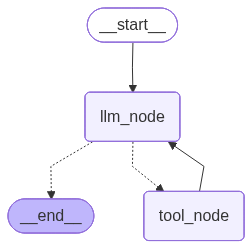

In [23]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

## Test: Save and Retrieve Notes

The agent decides which MCP tools to call based on the user's request.

In [24]:
result = await agent.ainvoke(
    {"messages": [{"role": "user", "content": "Save a note titled 'MCP' with content 'Model Context Protocol standardizes tool access for AI agents'"}]}
)

for msg in result["messages"]:
    msg.pretty_print()

Key 'additionalProperties' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring


================================ Human Message =================================

Save a note titled 'MCP' with content 'Model Context Protocol standardizes tool access for AI agents'
================================== Ai Message ==================================
Tool Calls:
  add_note (0efff7a0-2bc9-40c8-8e7c-5791bb6f04b0)
 Call ID: 0efff7a0-2bc9-40c8-8e7c-5791bb6f04b0
  Args:
    title: MCP
    content: Model Context Protocol standardizes tool access for AI agents
================================= Tool Message =================================

[{'type': 'text', 'text': "Note 'MCP' saved.", 'id': 'lc_96d561a0-4529-4cec-b428-f81a8dc0cb9d'}]
================================== Ai Message ==================================

I've saved the note titled 'MCP' with the content 'Model Context Protocol standardizes tool access for AI agents'.


In [25]:
result = await agent.ainvoke(
    {"messages": [{"role": "user", "content": "Save a note titled 'LangGraph' with content 'LangGraph builds agent workflows as explicit graphs with nodes and edges'"}]}
)

for msg in result["messages"]:
    msg.pretty_print()

Key 'additionalProperties' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring


================================ Human Message =================================

Save a note titled 'LangGraph' with content 'LangGraph builds agent workflows as explicit graphs with nodes and edges'
================================== Ai Message ==================================
Tool Calls:
  add_note (5a83dc43-3b02-4729-88f4-5dc213a5181a)
 Call ID: 5a83dc43-3b02-4729-88f4-5dc213a5181a
  Args:
    title: LangGraph
    content: LangGraph builds agent workflows as explicit graphs with nodes and edges
================================= Tool Message =================================

[{'type': 'text', 'text': "Note 'LangGraph' saved.", 'id': 'lc_777edfaa-cec6-4f1f-991b-0b8a2703c008'}]
================================== Ai Message ==================================

I've saved the note titled 'LangGraph' with the content you provided.


In [26]:
result = await agent.ainvoke(
    {"messages": [{"role": "user", "content": "List all my notes, then search for anything about 'agents'"}]}
)

final = result["messages"][-1]
content = final.content if isinstance(final.content, str) else final.content[0]["text"]
print(content)

Key 'additionalProperties' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring


I found these notes: 'Python tip, Meeting note, MCP, LangGraph'.

And searching for 'agents' returned this note: 'MCP: Model Context Protocol standardizes tool access for AI agents'.


## The Payoff: Swap the Server

The agent code above never mentions `add_note` or `search_notes`. It just calls `client.get_tools()` and binds whatever it finds.

Swap `notes_server.py` for a weather server, a database server, or a file manager — **the agent code stays exactly the same**. That's the power of a protocol.

## Key Takeaways

1. **`client.get_tools()` → `model.bind_tools(tools)`** — MCP tools plug directly into LangGraph with zero changes to the agent
2. **The agent never imports tool functions** — it discovers them at runtime through the protocol
3. **Swap the server, keep the agent** — change what tools are available without touching agent code